# CRPS and spread-skill ratio for the video PMD test-set ensemble

Verifies the 32-member ensemble from `global-1degree-24to3-pcn-v1`'s test-set
inference (endpoint-conditioned video diffusion: given observed 0h/24h daily
snapshots, infill the 7 interior 3-hourly frames). Two standard probabilistic
scores:

- **CRPS** (Continuous Ranked Probability Score): generalizes MAE to a full
  ensemble/distribution. Lower is better; a deterministic forecast's CRPS
  equals its MAE, so CRPS below the model's own ensemble-mean MAE means the
  ensemble spread is adding real skill, not just noise.
- **Spread-skill ratio**: ensemble spread (std across members, finite-ensemble
  corrected) divided by the ensemble-mean's RMSE against truth. A
  *reliable* ensemble has ratio approx 1 -- the spread should predict the
  actual error. Ratio < 1 is **underdispersive** (overconfident: true error
  is bigger than the ensemble admits); ratio > 1 is **overdispersive**
  (the ensemble is wider than it needs to be).

### Why "fair" CRPS

The naive plug-in CRPS estimator (`E|X-y| - 0.5*E|X-X'|` over the raw
ensemble, including self-pairs) is **biased high** for finite ensemble size
M -- at M=32 the bias is still a few percent. The "fair" estimator (Ferro et
al. 2008) excludes self-pairs, correcting this:

`CRPS_fair = mean_i|x_i - y| - 1/(M(M-1)) * sum_{i<j} |x_i - x_j|`

computed here via a memory-efficient sorted-order-statistics identity
(avoids an O(M^2) pairwise array at grid scale):
`sum_{i<j}|x_i-x_j| = sum_k (2k-M-1) x_(k)` for sorted `x_(1)<=...<=x_(M)`.

### Scope

Only **interior (generated) frames** are scored -- the 0h/24h endpoints are
deterministic broadcasts of the observed truth (by construction, see
`fme/downscaling/video_inference.py`), so they trivially have zero spread
and are not informative for probabilistic skill. `frame_source` in the
output zarr flags which is which.

Data: `PRED_ZARR` (our 32-member inference output) vs. `TRUTH_ZARR` (the
original SHiELD-AMIP store the model was trained/tested against). Period
below is a short 3-day window (Jan 1-4 2023) for a notebook that runs in a
reasonable time; extend `TIME_SLICE` to the full test period
(2023-01-01 to 2024-01-04) for final numbers.

In [1]:
import cftime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

plt.rcParams["figure.dpi"] = 100

In [2]:
PRED_ZARR = (
    "/climate-default/2026-06-25-temporal-diffusion/inference/"
    "global-1degree-24to3-pcn-v1/test-2023-2024-ens32.zarr"
)
TRUTH_ZARR = (
    "/climate-default/2026-06-25-temporal-diffusion/"
    "2025-07-25-X-SHiELD-AMIP-FME-3h.zarr"
)
CHANNELS = [
    "eastward_wind_at_ten_meters",
    "northward_wind_at_ten_meters",
    "PRMSL",
    "PRATEsfc",
]
UNITS = {
    "eastward_wind_at_ten_meters": "m/s",
    "northward_wind_at_ten_meters": "m/s",
    "PRMSL": "mb",
    "PRATEsfc": "kg/m2/s",
}
TIME_SLICE = (cftime.DatetimeJulian(2023, 1, 1), cftime.DatetimeJulian(2023, 1, 4))

pred = xr.open_zarr(PRED_ZARR).sel(time=slice(*TIME_SLICE))
truth_full = xr.open_zarr(TRUTH_ZARR).sel(time=slice(*TIME_SLICE))
# Predictions are on a lat_extent-cropped grid (176 of 180 raw latitudes);
# align truth to the exact same grid before comparing.
truth = truth_full.sel(latitude=pred.latitude, longitude=pred.longitude, method="nearest")

interior_mask = pred["frame_source"].values == 1
n_interior = int(interior_mask.sum())
print(
    f"{pred.sizes['time']} timesteps loaded, {n_interior} interior (generated), "
    f"ensemble={pred.sizes['ensemble']}, grid={pred.sizes['latitude']}x{pred.sizes['longitude']}"
)

lat = pred["latitude"].values
area_weight = np.cos(np.radians(lat))  # (lat,), broadcasts against (..., lat, lon)

25 timesteps loaded, 21 interior (generated), ensemble=32, grid=176x360


## Metric functions

In [3]:
def crps_fair(ens, truth_arr):
    """Fair (finite-ensemble-unbiased) CRPS. ``ens``: (..., M); ``truth_arr``:
    (...) broadcastable against ``ens[..., 0]``. Returns (...)."""
    M = ens.shape[-1]
    sorted_ens = np.sort(ens, axis=-1)
    k = np.arange(1, M + 1)
    weighted_sum = np.tensordot(sorted_ens, (2 * k - M - 1), axes=([-1], [0]))
    term2 = weighted_sum / (M * (M - 1))
    term1 = np.abs(ens - truth_arr[..., None]).mean(axis=-1)
    return term1 - term2


def area_weighted_mean(arr, lat_axis):
    """Weight by cos(lat) along ``lat_axis`` of an otherwise-arbitrary array."""
    shape = [1] * arr.ndim
    shape[lat_axis] = len(area_weight)
    w = area_weight.reshape(shape)
    w = np.broadcast_to(w, arr.shape)
    return np.sum(arr * w) / np.sum(w)


def spread_skill(ens, truth_arr, lat_axis, member_axis=-1):
    """(spread, rmse, ratio), area-weighted along ``lat_axis``, with the
    Fortin et al. (2014) finite-ensemble correction on spread
    (``sqrt((M+1)/M)``) so it's directly comparable to ensemble-mean RMSE for
    a reliable ensemble (ratio approx 1)."""
    M = ens.shape[member_axis]
    ens_mean = ens.mean(axis=member_axis)
    rmse = np.sqrt(area_weighted_mean((ens_mean - truth_arr) ** 2, lat_axis))
    var = ens.var(axis=member_axis, ddof=1)
    spread = np.sqrt(area_weighted_mean(var, lat_axis)) * np.sqrt((M + 1) / M)
    return spread, rmse, spread / rmse

## Global per-channel scores (all interior frames, Jan 1-4 2023)

In [4]:
rows = []
for name in CHANNELS:
    p = pred[name].isel(time=interior_mask).transpose("time", "latitude", "longitude", "ensemble").values
    t = truth[name].isel(time=interior_mask).transpose("time", "latitude", "longitude").values

    c = crps_fair(p, t)  # (time, lat, lon)
    crps_val = area_weighted_mean(c, lat_axis=1)
    spread, rmse, ratio = spread_skill(p, t, lat_axis=1)

    rows.append({
        "channel": name,
        "units": UNITS[name],
        "CRPS": crps_val,
        "spread": spread,
        "RMSE (ens mean)": rmse,
        "spread/skill ratio": ratio,
    })

summary = pd.DataFrame(rows).set_index("channel")
summary

,units,CRPS,spread,RMSE (ens mean),spread/skill ratio
channel,,,,,
eastward_wind_at_ten_meters,m/s,0.253136,0.537028,0.548984,0.978222
northward_wind_at_ten_meters,m/s,0.266668,0.561032,0.567545,0.988525
PRMSL,mb,0.196442,0.438062,0.430632,1.017253
PRATEsfc,kg/m2/s,0.000011,0.000060,0.000059,1.003041


## Skill vs. lead time within the 24h interpolation window

Each daily clip infills 7 interior frames at lead times 3h, 6h, ..., 21h
from the clip's start (0h). The frame at 12h is farthest from *either*
observed endpoint, so it's the hardest to predict -- CRPS should be worst
and, if the model is well-calibrated, spread should grow to match. This is
the direct analogue of the diurnal-cycle notebook's local-hour compositing,
but binning by "hours into the interpolation window" instead of local solar
time.

In [5]:
LEAD_HOURS = [3, 6, 9, 12, 15, 18, 21]
TIME_STEP_HOURS = 3
N_TIMESTEPS = 9  # clip length; matches config.model.n_timesteps
clip_stride = N_TIMESTEPS - 1

time_idx_in_clip = np.arange(pred.sizes["time"]) % clip_stride
# interior_mask already excludes idx 0 (endpoint); idx within [1, clip_stride-1]
# maps 1:1 to lead hours [3, 6, ..., 21].
lead_hour_per_step = time_idx_in_clip * TIME_STEP_HOURS

lead_rows = []
for name in CHANNELS:
    p_all = pred[name].transpose("time", "latitude", "longitude", "ensemble").values
    t_all = truth[name].transpose("time", "latitude", "longitude").values
    for lead in LEAD_HOURS:
        sel = interior_mask & (lead_hour_per_step == lead)
        if not sel.any():
            continue
        p, t = p_all[sel], t_all[sel]
        crps_val = area_weighted_mean(crps_fair(p, t), lat_axis=1)
        spread, rmse, ratio = spread_skill(p, t, lat_axis=1)
        lead_rows.append({
            "channel": name, "lead_hour": lead, "CRPS": crps_val,
            "spread": spread, "RMSE": rmse, "ratio": ratio,
        })

lead_df = pd.DataFrame(lead_rows)

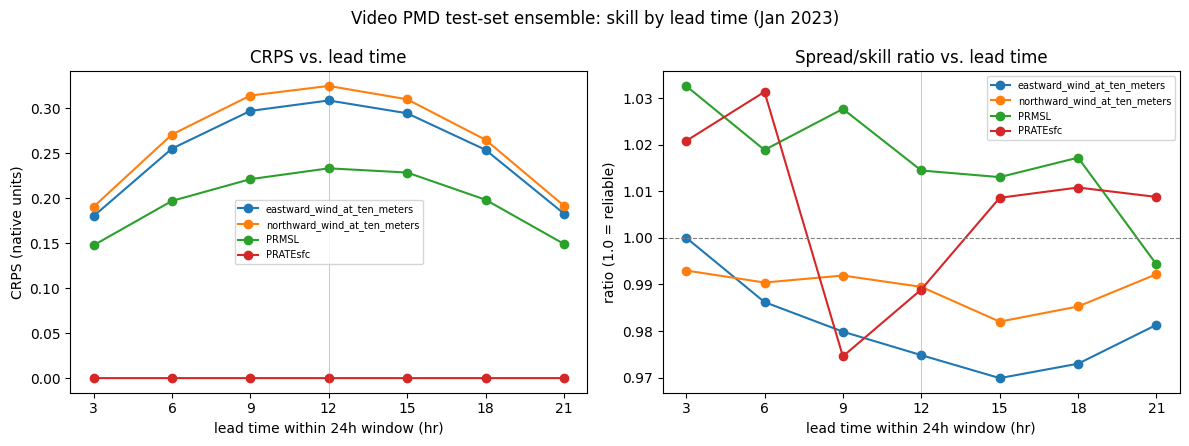

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name in CHANNELS:
    sub = lead_df[lead_df["channel"] == name]
    axes[0].plot(sub["lead_hour"], sub["CRPS"], marker="o", label=name)
    axes[1].plot(sub["lead_hour"], sub["ratio"], marker="o", label=name)

axes[0].set_title("CRPS vs. lead time")
axes[0].set_ylabel("CRPS (native units)")
axes[1].set_title("Spread/skill ratio vs. lead time")
axes[1].set_ylabel("ratio (1.0 = reliable)")
axes[1].axhline(1.0, color="gray", lw=0.8, ls="--")
for ax in axes:
    ax.set_xlabel("lead time within 24h window (hr)")
    ax.set_xticks(LEAD_HOURS)
    ax.axvline(12, color="gray", lw=0.6, alpha=0.5)
    ax.legend(fontsize=7)
fig.suptitle("Video PMD test-set ensemble: skill by lead time (Jan 1-4 2023)")
fig.tight_layout()

## Spatial map: CRPS at the hardest lead time (12h), PRMSL

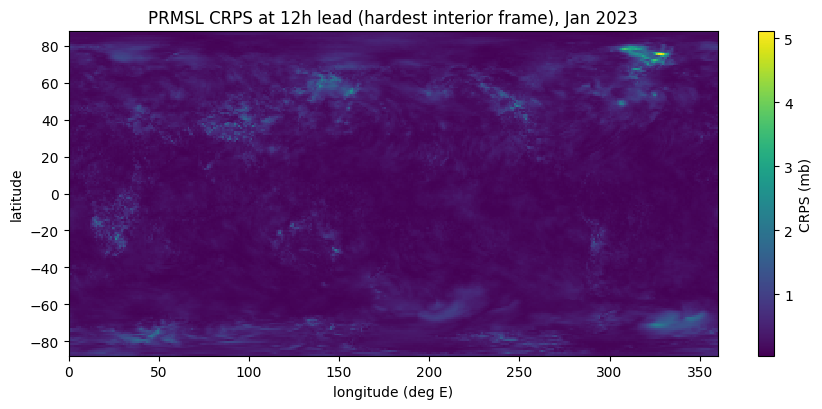

In [7]:
name = "PRMSL"
sel = interior_mask & (lead_hour_per_step == 12)
p = pred[name].isel(time=sel).transpose("time", "latitude", "longitude", "ensemble").values
t = truth[name].isel(time=sel).transpose("time", "latitude", "longitude").values
crps_map = crps_fair(p, t).mean(axis=0)  # (lat, lon)

fig, ax = plt.subplots(figsize=(9, 4.2))
im = ax.pcolormesh(pred["longitude"].values, lat, crps_map, cmap="viridis")
fig.colorbar(im, ax=ax, label=f"CRPS ({UNITS[name]})")
ax.set_xlabel("longitude (deg E)")
ax.set_ylabel("latitude")
ax.set_title(f"{name} CRPS at 12h lead (hardest interior frame), Jan 1-4 2023")
fig.tight_layout()

## Summary tables

In [8]:
print("Overall (all interior frames, Jan 1-4 2023):")
summary

Overall (all interior frames, Jan 1-4 2023):


,units,CRPS,spread,RMSE (ens mean),spread/skill ratio
channel,,,,,
eastward_wind_at_ten_meters,m/s,0.253136,0.537028,0.548984,0.978222
northward_wind_at_ten_meters,m/s,0.266668,0.561032,0.567545,0.988525
PRMSL,mb,0.196442,0.438062,0.430632,1.017253
PRATEsfc,kg/m2/s,0.000011,0.000060,0.000059,1.003041


In [9]:
print("By lead time:")
lead_df.round(4).set_index(["channel", "lead_hour"])

By lead time:


CRPS  spread    RMSE   ratio
channel                      lead_hour                                
eastward_wind_at_ten_meters  3          0.1800  0.3686  0.3686  1.0000
                             6          0.2551  0.5257  0.5330  0.9862
                             9          0.2970  0.6186  0.6313  0.9799
                             12         0.3086  0.6476  0.6644  0.9748
                             15         0.2944  0.6184  0.6376  0.9699
                             18         0.2538  0.5285  0.5431  0.9730
                             21         0.1829  0.3780  0.3852  0.9813
northward_wind_at_ten_meters 3          0.1905  0.3852  0.3880  0.9930
                             6          0.2708  0.5549  0.5603  0.9904
                             9          0.3141  0.6524  0.6577  0.9919
                             12         0.3248  0.6774  0.6846  0.9895
                             15         0.3100  0.6408  0.6526  0.9820
                             18         0.2649  0.5469  0.5550  0.9853
                             21         0.1916  0.3909  0.3940  0.9922
PRMSL                        3          0.1477  0.3124  0.3025  1.0326
                             6          0.1970  0.4239  0.4160  1.0189
                             9          0.2212  0.4931  0.4798  1.0277
                             12         0.2332  0.5176  0.5102  1.0145
                             15         0.2285  0.5076  0.5011  1.0130
                             18         0.1983  0.4436  0.4361  1.0172
                             21         0.1492  0.3172  0.3191  0.9943
PRATEsfc                     3          0.0000  0.0000  0.0000  1.0208
                             6          0.0000  0.0001  0.0001  1.0313
                             9          0.0000  0.0001  0.0001  0.9746
                             12         0.0000  0.0001  0.0001  0.9889
                             15         0.0000  0.0001  0.0001  1.0086
                             18         0.0000  0.0001  0.0001  1.0108
                             21         0.0000  0.0001  0.0001  1.0088